# Naive joint-circuit decomposition

Optimize a depth-$d$ ansatz `XX (RV ⊗ RV) XX (RV ⊗ RV) ... XX` end-to-end against a target's Makhlin invariants. This is what `gulps` deliberately avoids: the joint problem is $6(d-1)$ parameters against a 3-component residual — underdetermined, riddled with local minima, and pathological at degenerate Weyl faces. Gulps factors the same problem into independent segments using LP-chosen intermediate Weyl coordinates so each subproblem is a local 6-parameter solve.

The experiment: for each depth $d$, take the most extreme reachable point of the depth-$d$ Weyl polytope (the vertex with largest $c_3$) as a single hard target, then run `num_trials` independent random restarts of Levenberg–Marquardt on the Makhlin residual and count how many converge.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from tqdm.auto import tqdm

from qiskit.circuit.library import iSwapGate
from qiskit._accelerate.two_qubit_decompose import (
    two_qubit_local_invariants as tqli,
)
from monodromy.coordinates import monodromy_to_positive_canonical_coordinate

from gulps import GateInvariants
from gulps.core.isa import ContinuousISA
from gulps.core.coverage import isa_to_coverage
from gulps.viz.invariant_viz import scatter_plot
from gulps.viz.polytope_viz import plot_coverage_set

import lusca  # noqa: F401

%load_ext lusca.mpl_freeze

In [2]:
xx_gate = iSwapGate().power(1 / 4)
basis_gate = np.asarray(xx_gate.to_matrix(), dtype=np.complex128)

isa = ContinuousISA.from_base_gate(xx_gate, name="xx")
coverage_set = isa_to_coverage(isa)
for p in coverage_set:
    print(f"depth={len(p.instructions)}  cost={p.cost:.4f}")

depth=0  cost=0.0000
depth=1  cost=1.0000
depth=2  cost=2.0000
depth=3  cost=3.0000
depth=4  cost=4.0000
depth=5  cost=5.0000
depth=6  cost=6.0000


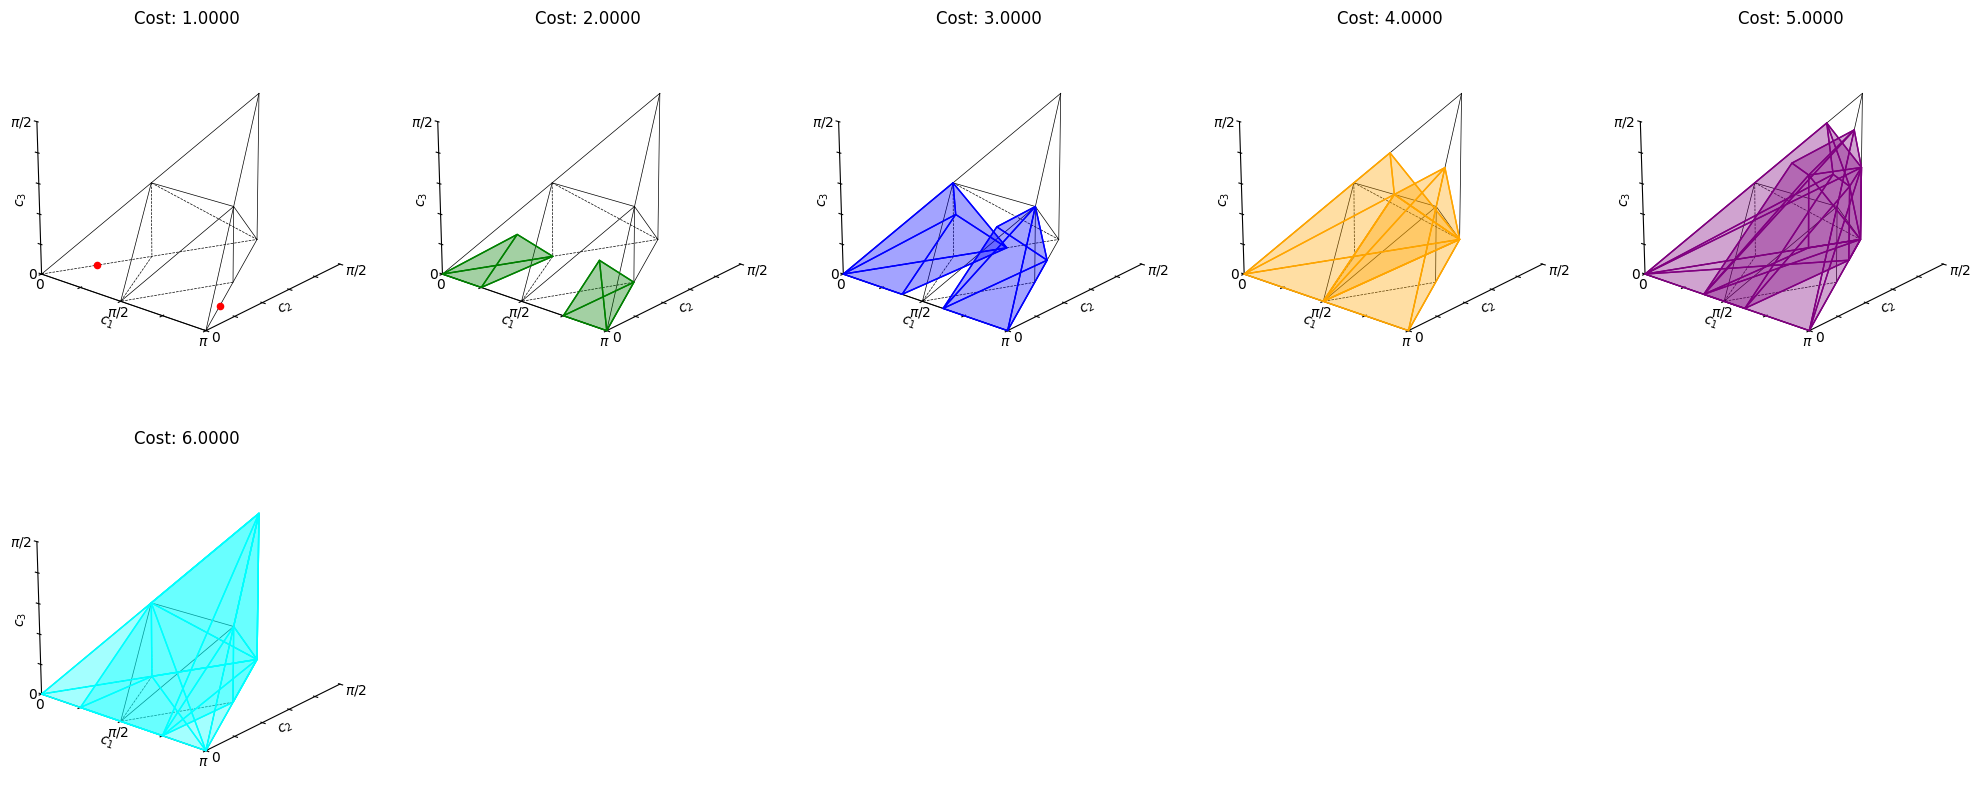

In [3]:
plot_coverage_set(coverage_set)
plt.show()

In [4]:
def _rv(v):
    """Numpy port of qiskit.circuit.library.RVGate matrix."""
    h = np.linalg.norm(v) / 2
    if h < 1e-15:
        return np.eye(2, dtype=np.complex128)
    nx, ny, nz = v / (2 * h)
    s, c = np.sin(h), np.cos(h)
    return np.array(
        [[c - 1j * nz * s, (-ny - 1j * nx) * s], [(ny - 1j * nx) * s, c + 1j * nz * s]],
        dtype=np.complex128,
    )


def construct_op(x):
    """Build U = XX (RV⊗RV) XX ... XX from flat 6(d-1)-vector x; depth inferred."""
    d = x.shape[0] // 6 + 1
    U = basis_gate
    for i in range(d - 1):
        local = np.kron(_rv(x[6 * i : 6 * i + 3]), _rv(x[6 * i + 3 : 6 * i + 6]))
        U = basis_gate @ local @ U
    return U


def residual(x, target_makhlin):
    return np.asarray(tqli(construct_op(x))) - target_makhlin

In [5]:
def optimize_circuit(num_params, target_makhlin, threshold=1e-8, max_restarts=1):
    """Single-shot LM on the Makhlin residual. Converged iff every component < threshold.

    method="trf" rather than "lm" because MINPACK lmdif requires
    n_residuals >= n_params, but we always have 3 residuals against 6(d-1) params.

    Tolerances at machine epsilon (1e-15 — scipy refuses literal zero) so TRF
    runs to the iteration cap instead of exiting on a small step. Old jaxopt
    code achieved this with tol=0; default scipy 1e-8 quits at ~40 nfev with
    residual still at 1e-7, masking real convergence.
    """
    for _ in range(max_restarts):
        x0 = np.random.uniform(-2 * np.pi, 2 * np.pi, num_params)
        res = least_squares(
            residual,
            x0,
            args=(target_makhlin,),
            method="trf",
            xtol=1e-15,
            ftol=1e-15,
            gtol=1e-15,
            max_nfev=2048,
        )
        if np.all(np.abs(res.fun) < threshold):
            return True
    return False

In [6]:
def sample_polytope_surface(vertices, n_samples=1):
    """Faithful port: return the vertex with the largest c3, repeated n_samples times."""
    vertices = np.asarray(vertices)
    max_z_vertex = vertices[np.argmax(vertices[:, 2])]
    return np.tile(max_z_vertex, (n_samples, 1))

In [7]:
def surface_sample(depth, n_samples):
    """Pick targets on the surface of the depth-d polytope and visualize them."""
    polytope = coverage_set[depth]
    polytope_vertices = np.array(
        [
            monodromy_to_positive_canonical_coordinate(*v)
            for v in polytope.reduce().vertices[0]
        ]
    ) / (np.pi / 2)

    points = sample_polytope_surface(polytope_vertices, n_samples)
    targets = [GateInvariants.from_weyl(tuple(p)) for p in points]

    fig, ax = scatter_plot(targets, color="black", s=40)
    ax.set_title(f"depth-{depth} target (c1,c2,c3)={tuple(np.round(points[0], 3))}")
    plt.show()
    return targets


Depth = 2  (6 parameters)


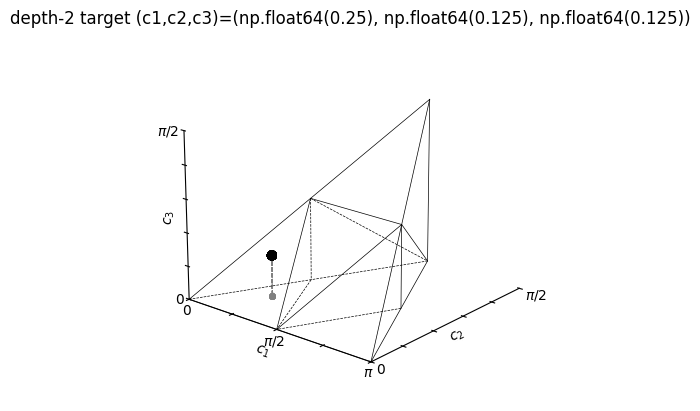

depth 2: 100%|██████████| 32/32 [00:02<00:00, 15.46it/s]


  converged: 32/32

Depth = 3  (12 parameters)


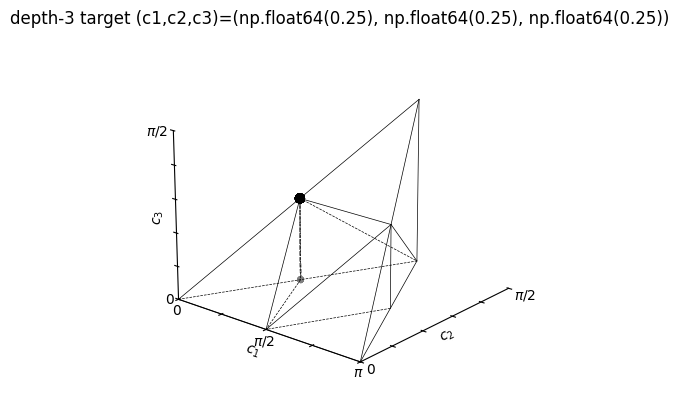

depth 3: 100%|██████████| 32/32 [00:35<00:00,  1.12s/it]

  converged: 32/32

Depth = 4  (18 parameters)


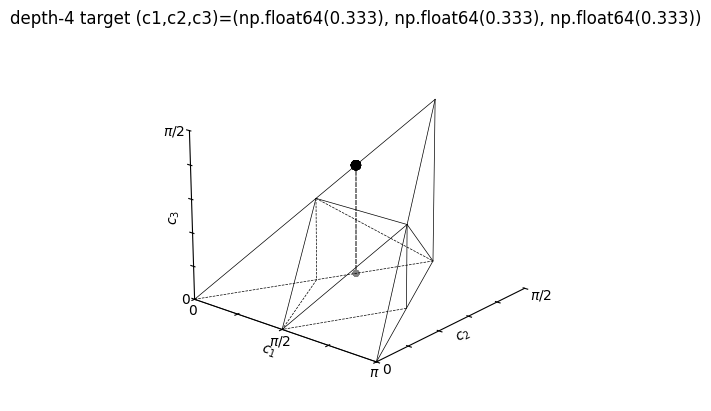

depth 4: 100%|██████████| 32/32 [03:02<00:00,  5.70s/it]

  converged: 3/32

Depth = 5  (24 parameters)


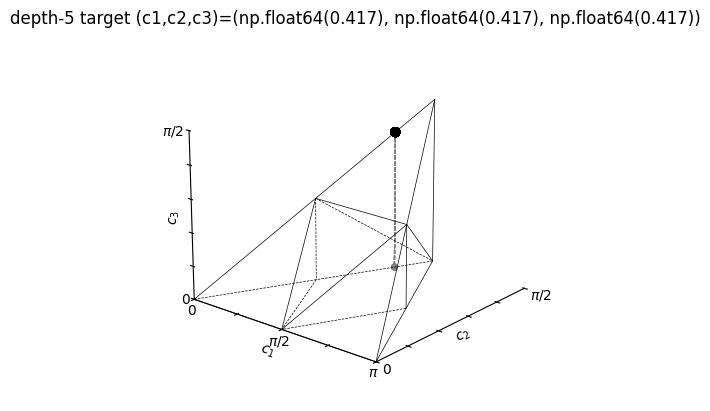

depth 5: 100%|██████████| 32/32 [05:21<00:00, 10.05s/it]

  converged: 1/32

Depth = 6  (30 parameters)


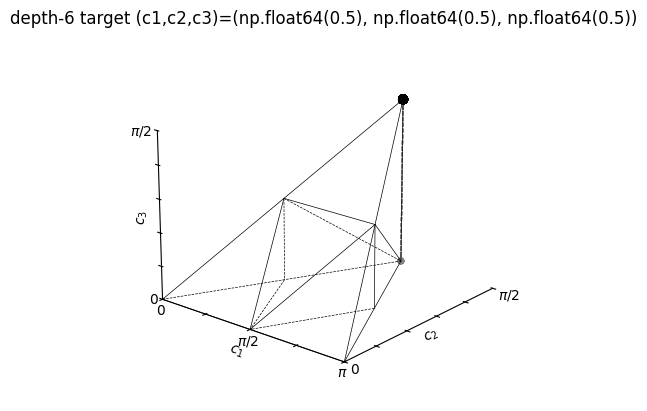

depth 6: 100%|██████████| 32/32 [07:36<00:00, 14.25s/it]

  converged: 0/32


In [8]:
depths = [2, 3, 4, 5, 6]
num_trials = 32  # Without JAX jit, FD Jacobians make this expensive at high depth.
results = {d: [] for d in depths}

for d in depths:
    num_params = 6 * (d - 1)
    print(f"\nDepth = {d}  ({num_params} parameters)")
    targets = surface_sample(d, num_trials)
    for tgt in tqdm(targets, desc=f"depth {d}"):
        results[d].append(optimize_circuit(num_params, np.asarray(tgt.makhlin)))
    print(f"  converged: {sum(results[d])}/{num_trials}")

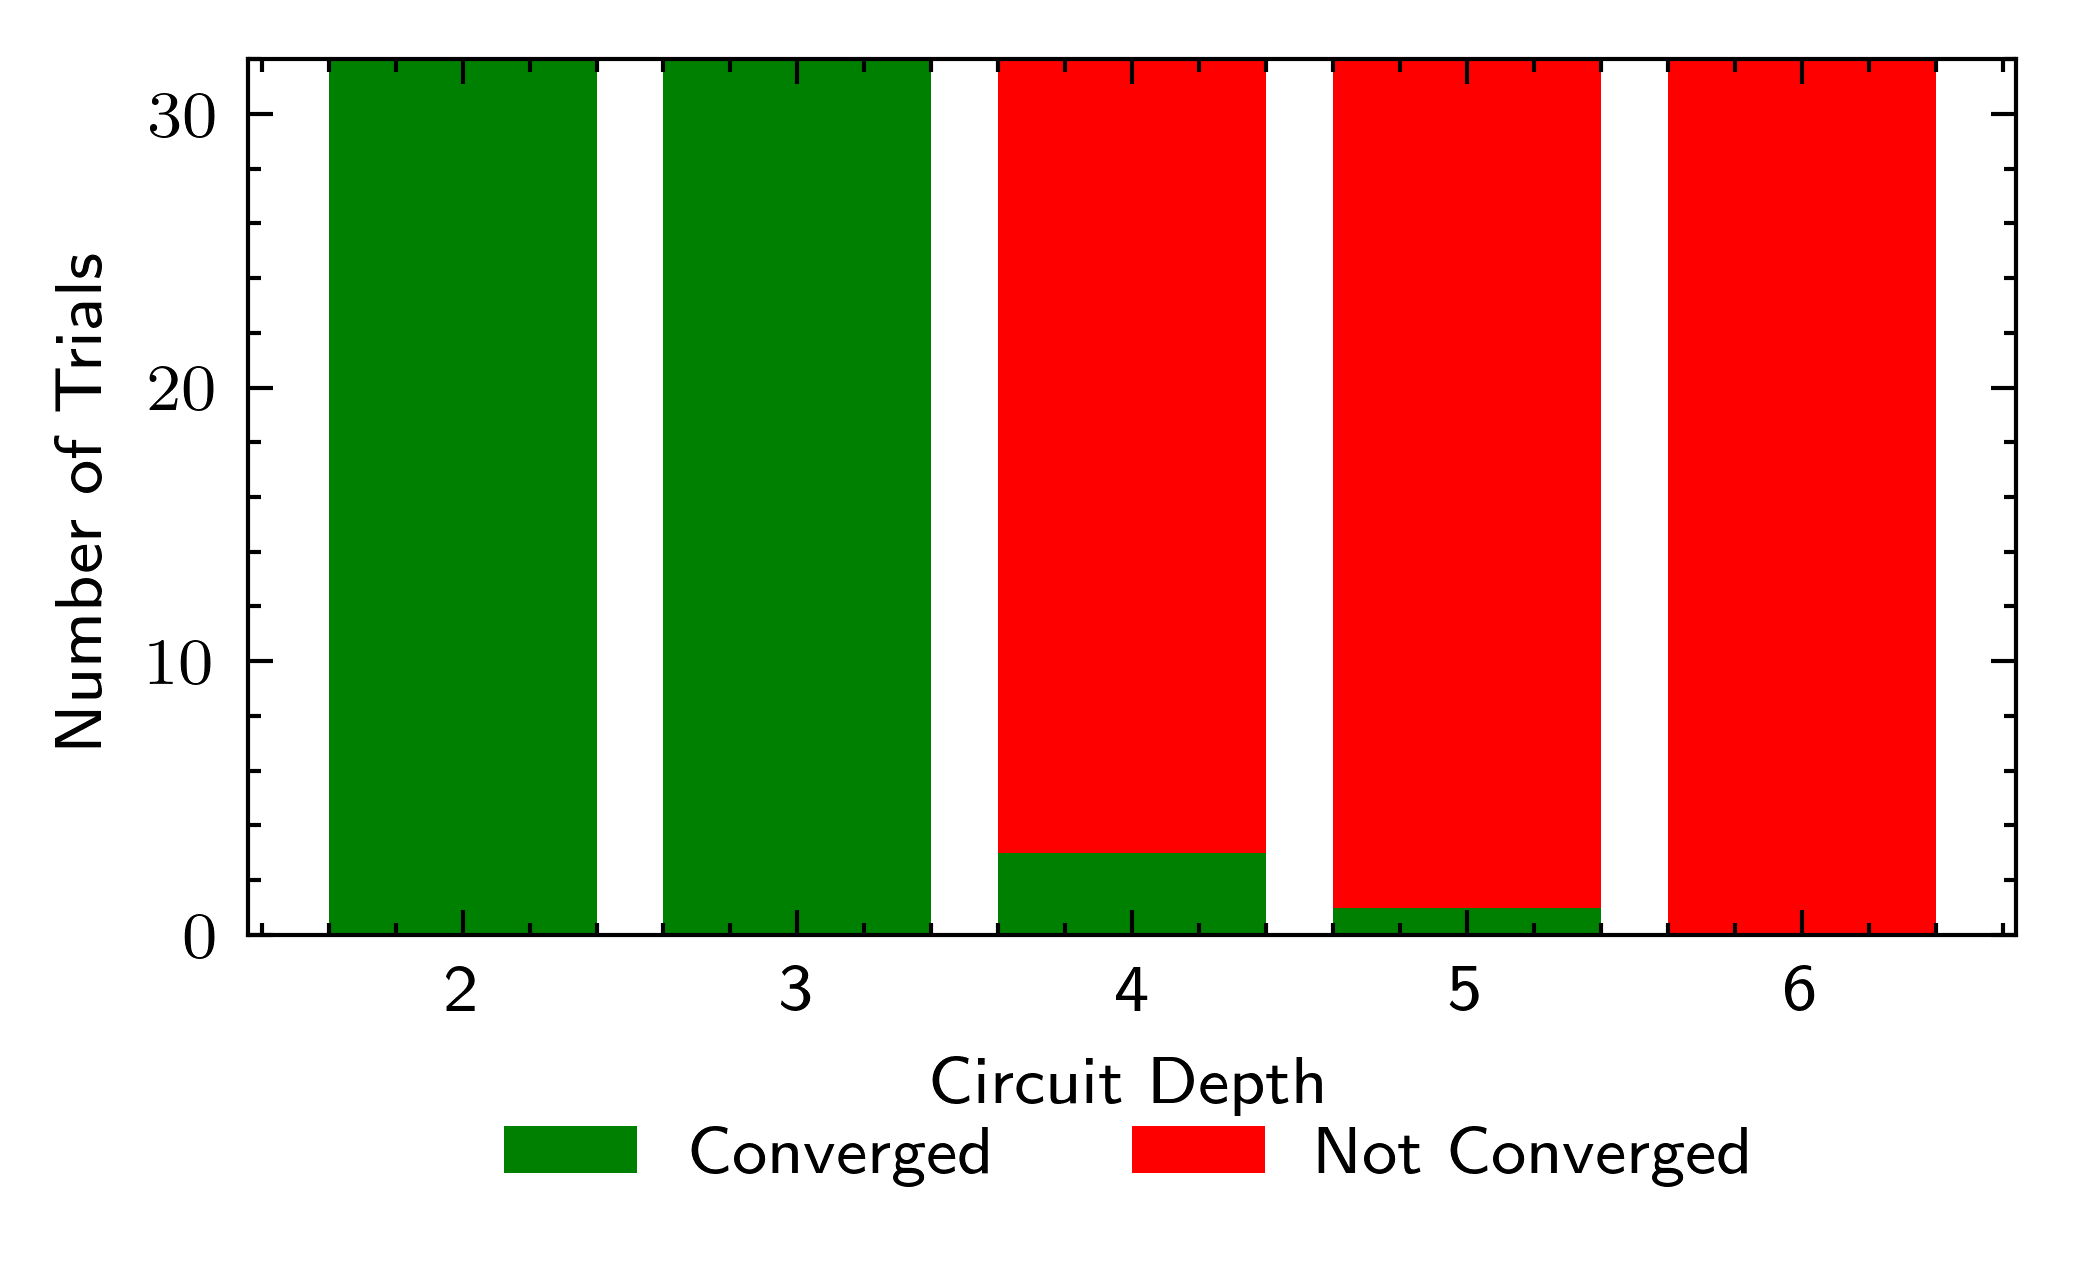

In [12]:
%%mplfreeze convergence_plot results --outdir figs/
depths_sorted = sorted(results.keys())
converged_counts = [sum(results[d]) for d in depths_sorted]
non_converged_counts = [
    len(results[d]) - c for c, d in zip(converged_counts, depths_sorted)
]

with plt.style.context("lusca"):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.2))
    x = np.arange(len(depths_sorted))
    ax.bar(x, converged_counts, color="green", label="Converged")
    ax.bar(
        x,
        non_converged_counts,
        bottom=converged_counts,
        color="red",
        label="Not Converged",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(depths_sorted)
    ax.set_xlabel("Circuit Depth")
    ax.set_ylabel("Number of Trials")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
    fig.tight_layout()
plt.show()